# Correlation: Spearman's Rank

In Chapter 1: Describing Data we introduced **Spearman's rank correlation coefficient**, a correlation measure based on ranks that is robust to non-Normality and outliers.

**If you are unsure about correlation coefficients, please revisit the page on correlation in Chapter 1: Describing Data.**

As a quick summary, Pearson’s correlation coefficient relies on several assumptions:

- The relationship between the two variables is **linear** (i.e. it follows a straight line, not a curve).
- The variance of the data is roughly constant across the range of the variables (no **heteroscedasticity**).
- There are no extreme or influential outliers.

If these assumptions are not met, it is generally preferable to use **Spearman’s rank correlation coefficient** instead.

In this section we revisit Spearman's $(r)$ and show how to obtain a $p-value$ for it using `scipy.stats`.


In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings 
warnings.simplefilter('ignore', category=FutureWarning)

## Example: wealth and carbon emissions

We will use the CO\(_2\) dataset discussed in the section on correlation in Chapter 1: Describing Data. This dataset contains measures of GDP (wealth) and carbon emissions per person for 164 countries.

Here we are interested in knowing whether richer countries tend to emit more CO\(_2\) per person than poorer countries.

**Question:** test whether there is an association between GDP and carbon emissions per person.

*Notes:*
- Both variables are continuous.
- Inspection of the scatter plot suggests that the relationship is approximately **linear**, but the spread of emissions increases with GDP (i.e. the data show **heteroscedasticity**).
- There are also several extreme values.
- Because the assumptions of Pearson’s correlation are not met, **Spearman’s rank correlation** is a more appropriate choice.
- Decide whether you want a **two-sided** test (any association) or a **one-sided** test (e.g. higher GDP is associated with higher emissions).

*Practical steps*
1. Inspect the data.  
2. State the formal hypotheses.  
3. Compute Spearman’s rank correlation coefficient.  
4. Obtain the associated p-value using `scipy.stats`.  
5. Draw conclusions.


### 1. Inspect the data

We will use the CO\(_2\) dataset discussed in the section on correlation in Chapter 1: Describing Data. This dataset contains measures of GDP (wealth) and carbon emissions per person for 164 countries.

In [2]:
carbon = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/CO2vGDP.csv')
carbon

,Country,CO2,GDP,population
0,Afghanistan,0.2245,1934.555054,36686788
1,Albania,1.6422,11104.166020,2877019
2,Algeria,3.8241,14228.025390,41927008
3,Angola,0.7912,7771.441895,31273538
4,Argentina,4.0824,18556.382810,44413592
...,...,...,...,...
159,Venezuela,4.1602,10709.950200,29825652
160,Vietnam,2.3415,6814.142090,94914328
161,Yemen,0.3503,2284.889893,30790514
162,Zambia,0.4215,3534.033691,17835898


Let's plot the data to get an idea of whether our assumptions are met. 

From the scatter plot, we can see that the data are not well suited to Pearson’s correlation (please revisit the notes on correlation in **Chapter 1: Describing Data** if you are unsure why).


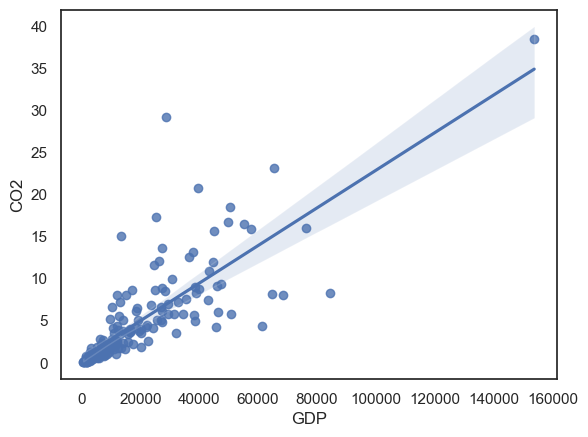

In [3]:
sns.regplot(data=carbon, x='GDP', y='CO2')
plt.show()

Comments:

- There is a clear positive association between GDP and CO\(_2\) emissions per person: countries with higher GDP tend to emit more CO\(_2\) per person.
- The relationship appears approximately **linear on average**, as indicated by the fitted line.
- The spread of CO2 emissions increases with GDP, showing clear **heteroscedasticity** (greater variability among wealthier countries).
- There are several high-GDP, high-emissions countries that act as influential points and would have a strong effect on Pearson’s correlation.
- Despite these features, the overall **monotonic** relationship (higher GDP → higher emissions) is clear, making Spearman’s rank correlation an appropriate choice.


### 2. Hypotheses

**IMPORTANT NOTE:**

For **Pearson's correlation** (the 'standard' correlation coefficient, calculated on actual data values rather than ranks) we might express our null and alternative hypotheses as follows:

$\mathcal{H_o}$ There is no linear relationship between GDP and CO2 emissions per capita

$\mathcal{H_a}$ There is a positive linear relationship between GDP and CO2 emissions per capita
* in plain English, CO2 emissions are proportional to GDP


*(remember from the section on correlation in **Describing Data** that Pearson's correlation assumes that the relationship, if there is one, is a straight line)*

<br>

For **Spearman's rank correlation** coefficient, our null and alternative hypotheses are slightly different:

$\mathcal{H_o}$ There is no relationship between GDP and CO2 emissions per capita

$\mathcal{H_a}$ There is a positive relationship between CO2 and GDP rank
* in plain English, richer a country is, the higher its carbon emissions, note we've dropped the linear...

### 3. Calculating correlation

We have seen that we can get the correlation ($r$-value) between all pairs of columns using a `pandas` function `df.corr()` as follows:

In [4]:
carbon.corr(numeric_only=True, method='spearman')

,CO2,GDP,population
CO2,1.000000,0.914369,-0.098554
GDP,0.914369,1.000000,-0.122920
population,-0.098554,-0.122920,1.000000


Or between two particular columns like this:

In [5]:
carbon.GDP.corr(carbon.CO2, method='spearman')

np.float64(0.9143688871356085)

### 4. Obtain the p-value

The `pandas` function `df.corr()` computes the value of the correlation coefficient, but it does not provide a test of statistical significance.

As before, we could obtain a p-value using a permutation test, but we can also use a built-in function from `scipy.stats` called `stats.spearmanr`, which returns both Spearman’s rank correlation coefficient and its associated p-value.


In [6]:
stats.spearmanr(carbon.GDP, carbon.CO2)

SignificanceResult(statistic=np.float64(0.9143688871356085), pvalue=np.float64(1.6676605949335523e-65))

### 5. Draw conclusions

Spearman’s rank correlation indicates a statistically significant positive association between GDP and CO2 emissions per person becuase the $p$-value $1.7 \times 10^{-65}$ is less than our chosen significance level ($\alpha = 0.05$. In fact, its a lot less...

The strength of the association is reflected in the value of Spearman’s \(r = 0.91\), which indicates a very strong positive relationship.